Libraries loaded successfully
Dataset shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  


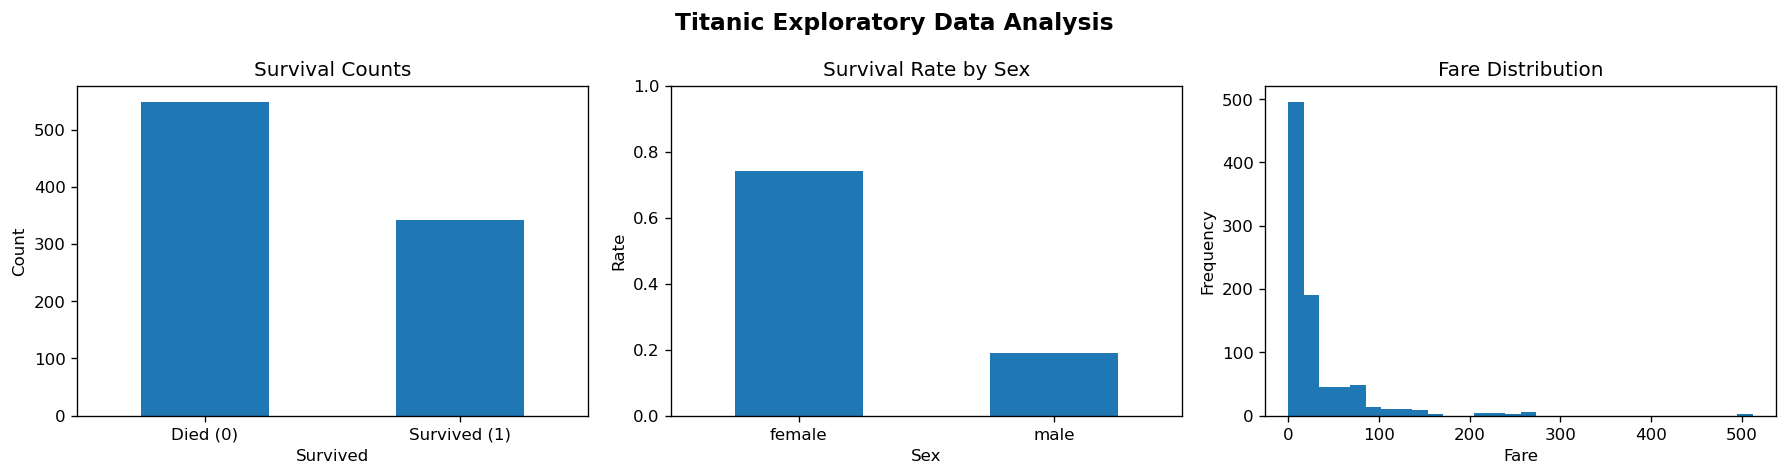


Remaining missing values:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Data prepared
X_train shape: (712, 7)
X_test shape: (179, 7)

Training Simple NN...


/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Training Deep NN...

=== RESULTS ===
Simple NN -> Accuracy: 0.7933 | AUC: 0.8542
Deep NN   -> Accuracy: 0.7765 | AUC: 0.8300


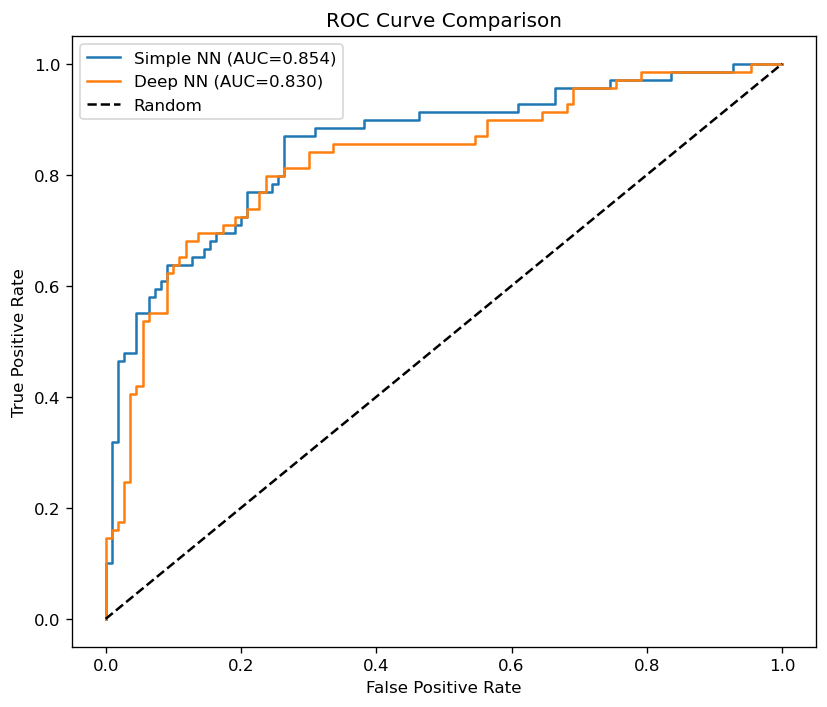

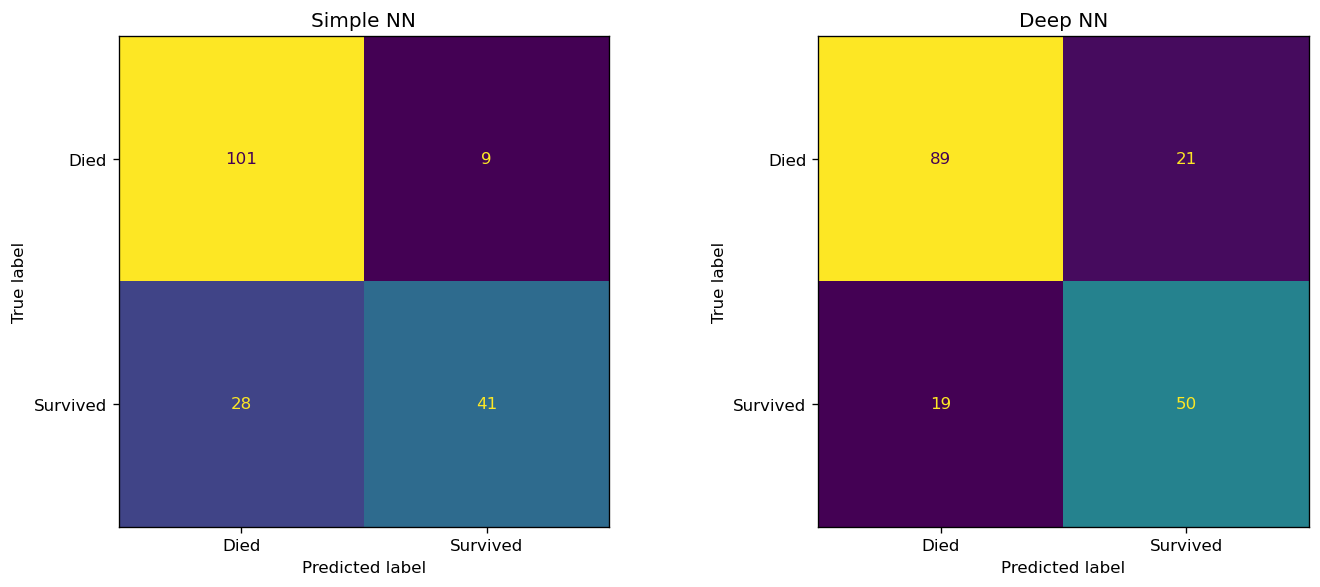


--- Classification Report: Simple NN ---
              precision    recall  f1-score   support

           0       0.78      0.92      0.85       110
           1       0.82      0.59      0.69        69

    accuracy                           0.79       179
   macro avg       0.80      0.76      0.77       179
weighted avg       0.80      0.79      0.79       179


--- Classification Report: Deep NN ---
              precision    recall  f1-score   support

           0       0.82      0.81      0.82       110
           1       0.70      0.72      0.71        69

    accuracy                           0.78       179
   macro avg       0.76      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



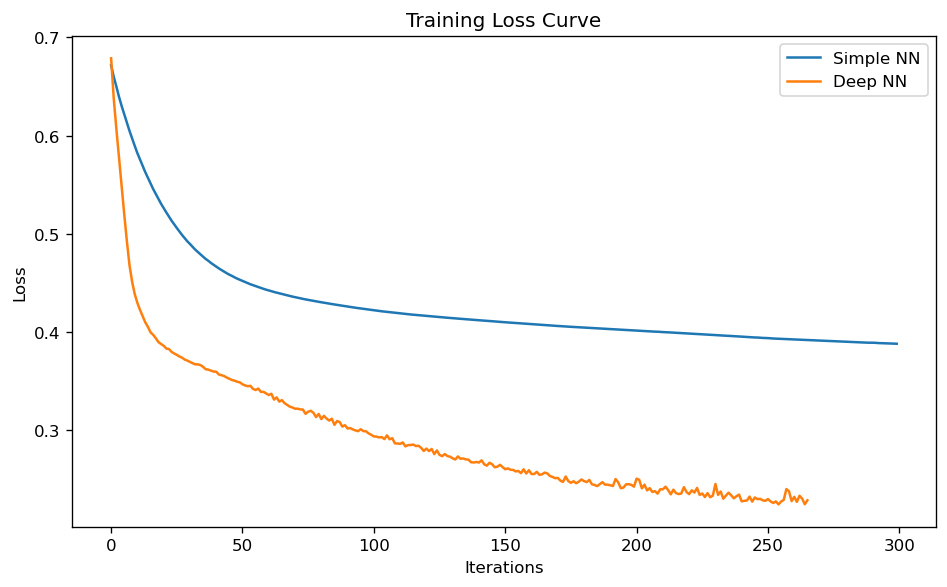


Summary:
       Model  Accuracy      AUC
0  Simple NN  0.793296  0.85415
1    Deep NN  0.776536  0.83004


In [7]:
# Install needed libraries
%pip install pandas numpy matplotlib scikit-learn --quiet

# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    accuracy_score,
    ConfusionMatrixDisplay
)
from sklearn.neural_network import MLPClassifier

# =========================
# SETTINGS
# =========================
SEED = 42
np.random.seed(SEED)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10

print("Libraries loaded successfully")

# =========================
# LOAD DATASET
# =========================
df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset shape:", df.shape)
print(df.head())

# =========================
# BASIC CHECKS
# =========================
print("\nSurvived counts:")
print(df["Survived"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

# =========================
# EDA
# =========================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Titanic Exploratory Data Analysis", fontsize=14, fontweight="bold")

# Survival counts
df["Survived"].value_counts().plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("Survival Counts")
axes[0].set_xticklabels(["Died (0)", "Survived (1)"])
axes[0].set_ylabel("Count")

# Survival by sex
df.groupby("Sex")["Survived"].mean().plot(kind="bar", ax=axes[1], rot=0)
axes[1].set_title("Survival Rate by Sex")
axes[1].set_ylabel("Rate")
axes[1].set_ylim(0, 1)

# Fare distribution
axes[2].hist(df["Fare"], bins=30)
axes[2].set_title("Fare Distribution")
axes[2].set_xlabel("Fare")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# =========================
# PREPROCESSING
# =========================
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Embarked"] = df["Embarked"].map({"C": 0, "Q": 1, "S": 2})

print("\nRemaining missing values:")
print(df.isnull().sum())

# =========================
# FEATURES AND TARGET
# =========================
X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nData prepared")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# =========================
# MODEL 1: SIMPLE NN
# =========================
simple_nn = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation="relu",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=300,
    random_state=SEED
)

# =========================
# MODEL 2: DEEP NN
# =========================
deep_nn = MLPClassifier(
    hidden_layer_sizes=(64, 64, 32, 16),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=300,
    random_state=SEED
)

# =========================
# TRAIN MODELS
# =========================
print("\nTraining Simple NN...")
simple_nn.fit(X_train, y_train)

print("Training Deep NN...")
deep_nn.fit(X_train, y_train)

# =========================
# PREDICTIONS
# =========================
probs_simple = simple_nn.predict_proba(X_test)[:, 1]
probs_deep = deep_nn.predict_proba(X_test)[:, 1]

preds_simple = (probs_simple >= 0.5).astype(int)
preds_deep = (probs_deep >= 0.5).astype(int)

# =========================
# METRICS
# =========================
auc_simple = roc_auc_score(y_test, probs_simple)
auc_deep = roc_auc_score(y_test, probs_deep)

acc_simple = accuracy_score(y_test, preds_simple)
acc_deep = accuracy_score(y_test, preds_deep)

print("\n=== RESULTS ===")
print(f"Simple NN -> Accuracy: {acc_simple:.4f} | AUC: {auc_simple:.4f}")
print(f"Deep NN   -> Accuracy: {acc_deep:.4f} | AUC: {auc_deep:.4f}")

# =========================
# ROC CURVE
# =========================
fpr_s, tpr_s, _ = roc_curve(y_test, probs_simple)
fpr_d, tpr_d, _ = roc_curve(y_test, probs_deep)

plt.figure(figsize=(7, 6))
plt.plot(fpr_s, tpr_s, label=f"Simple NN (AUC={auc_simple:.3f})")
plt.plot(fpr_d, tpr_d, label=f"Deep NN (AUC={auc_deep:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# CONFUSION MATRICES
# =========================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_simple = confusion_matrix(y_test, preds_simple)
cm_deep = confusion_matrix(y_test, preds_deep)

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_simple, display_labels=["Died", "Survived"])
disp1.plot(ax=axes[0], values_format="d", colorbar=False)
axes[0].set_title("Simple NN")

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_deep, display_labels=["Died", "Survived"])
disp2.plot(ax=axes[1], values_format="d", colorbar=False)
axes[1].set_title("Deep NN")

plt.tight_layout()
plt.show()

# =========================
# CLASSIFICATION REPORTS
# =========================
print("\n--- Classification Report: Simple NN ---")
print(classification_report(y_test, preds_simple))

print("\n--- Classification Report: Deep NN ---")
print(classification_report(y_test, preds_deep))

# =========================
# TRAINING LOSS CURVES
# =========================
plt.figure(figsize=(8, 5))
plt.plot(simple_nn.loss_curve_, label="Simple NN")
plt.plot(deep_nn.loss_curve_, label="Deep NN")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# SUMMARY TABLE
# =========================
summary = pd.DataFrame({
    "Model": ["Simple NN", "Deep NN"],
    "Accuracy": [acc_simple, acc_deep],
    "AUC": [auc_simple, auc_deep]
})

print("\nSummary:")
print(summary)